<a href="https://colab.research.google.com/github/Chaitanya15-ai/codealpha_datascience/blob/main/Codealpha_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Model Performance
R² Score : 0.899438024100912
MAE : 1.4607567168117603
RMSE : 1.78159966153345

Predicted Sales: 19.63


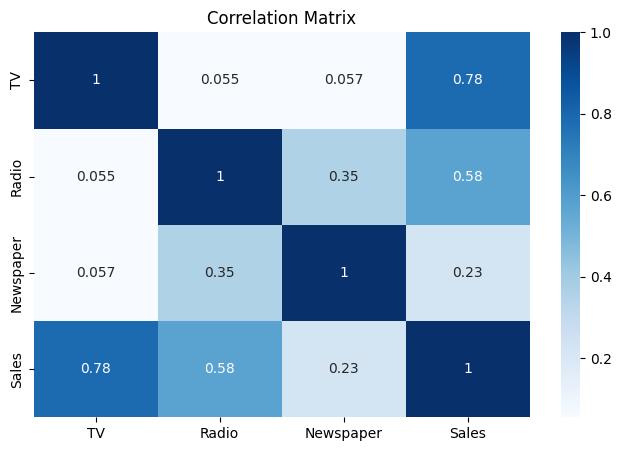

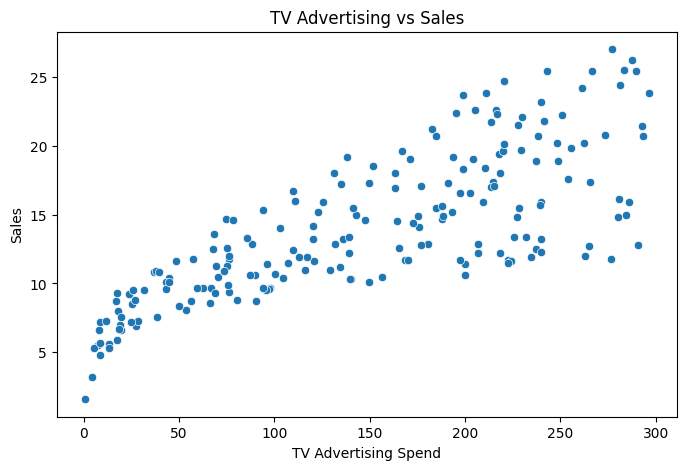

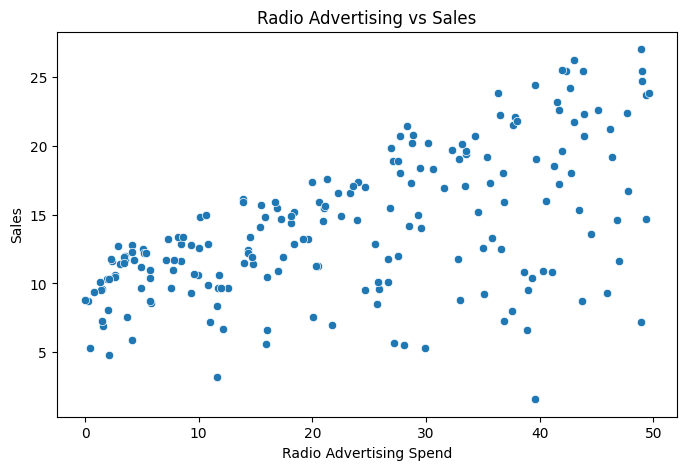

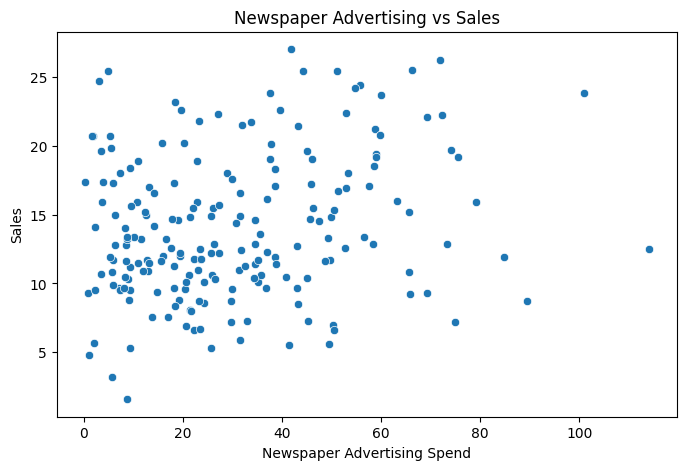

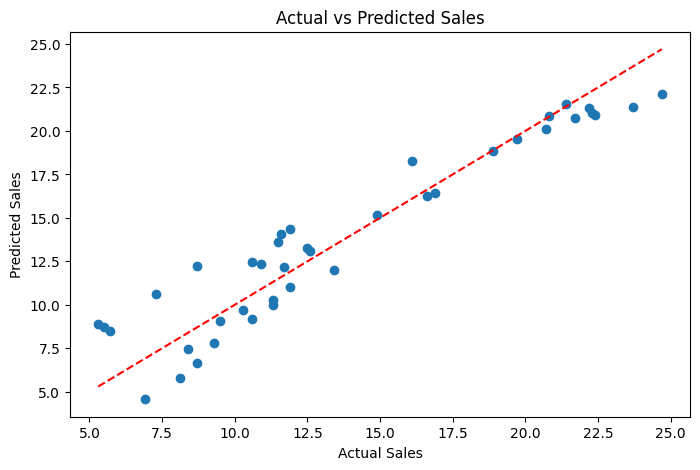

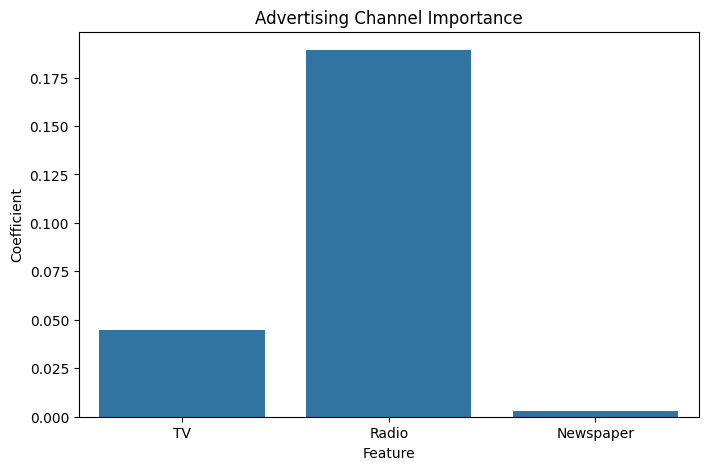

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("Advertising.csv")

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

print(df.head())

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Performance")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

future_data = pd.DataFrame({
    "TV": [200],
    "Radio": [40],
    "Newspaper": [50]
})

future_sales = model.predict(future_data)

print("\nPredicted Sales:", round(future_sales[0], 2))

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Feature", y="Coefficient")
plt.title("Advertising Channel Importance")
plt.show()